# Assign geojson shapes to rasterised array

Work out which geojson polygons go into each pixel of a raster array. Store the lookup.

## Code setup

In [313]:
import numpy as np
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
# For converting geojson shapes to raster (array):
import rasterio
from rasterio import features

## Load data

LSOA shapes:

In [314]:
path_to_lsoa = os.path.join('..', 'data_geojson', 'ons_data', 'LSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3.geojson')

gdf_lsoa = gpd.read_file(path_to_lsoa)

In [315]:
gdf_lsoa.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E01000001,City of London 001A,City of London 001A,532129,181625,-0.097060,51.51810,283b0ead-f8fc-40b6-9a79-1ddd7e5c0758,"POLYGON ((532105.092 182011.23, 532162.491 181..."
1,2,E01000002,City of London 001B,City of London 001B,532480,181699,-0.091970,51.51868,ddce266b-7825-428c-9e0a-df66b0179a55,"POLYGON ((532634.497 181926.016, 532619.141 18..."
2,3,E01000003,City of London 001C,City of London 001C,532245,182036,-0.095230,51.52176,c45e358e-a794-485a-bf76-d96e5d458ea4,"POLYGON ((532135.138 182198.131, 532158.25 182..."
3,4,E01000005,City of London 001E,City of London 001E,533581,181265,-0.076280,51.51452,4ddaf5e4-e47f-4312-89a0-923ffec028a6,"POLYGON ((533808.018 180767.774, 533649.037 18..."
4,5,E01000006,Barking and Dagenham 016A,Barking and Dagenham 016A,544994,184276,0.089318,51.53876,1c04702a-b662-4cfc-aab9-2c3e0f2d5e29,"POLYGON ((545122.049 184314.931, 545271.849 18..."


Region data:

In [316]:
df_lsoa_icb = pd.read_csv(os.path.join('..', 'data_tabular', 'regions_lsoa_ew.csv'))

df_lsoa_icb.head()

,LSOA11NM,LSOA11CD,LOC22CD,LOC22NM,ICB22CD,ICB22NM,LHB20CD,LHB20NM,LHB20NMW
0,Hartlepool 006B,E01011966,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,NaN,NaN,NaN
1,Hartlepool 005B,E01011974,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,NaN,NaN,NaN
2,Hartlepool 006A,E01011965,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,NaN,NaN,NaN
3,Hartlepool 006C,E01011983,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,NaN,NaN,NaN
4,Hartlepool 008A,E01011950,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,NaN,NaN,NaN


In [317]:
df_icb_regions = pd.read_csv(os.path.join('..', 'data_tabular', 'regions_ew.csv'))

df_icb_regions.head()

,RGN11NM,CTRY11NM,LHB20CD,LHB20NM,LHB20NMW,LOC22CD,LOC22NM,ICB22CD,ICB22NM,ISDN,ambulance_service
0,North East,England,NaN,NaN,NaN,E38000247,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East
1,North West,England,NaN,NaN,NaN,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,NHS Cheshire and Merseyside Integrated Care Board,Cheshire and Merseyside,North West
2,North West,England,NaN,NaN,NaN,E38000194,NHS Cheshire and Merseyside ICB - 02E,E54000008,NHS Cheshire and Merseyside Integrated Care Board,Cheshire and Merseyside,North West
3,North West,England,NaN,NaN,NaN,E38000014,NHS Lancashire and South Cumbria ICB - 00Q,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,Lancashire and South Cumbria,North West
4,North West,England,NaN,NaN,NaN,E38000015,NHS Lancashire and South Cumbria ICB - 00R,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,Lancashire and South Cumbria,North West


In [318]:
df_lsoa_icb = pd.merge(df_lsoa_icb[['LSOA11NM', 'LSOA11CD', 'LOC22CD']], df_icb_regions, on='LOC22CD', how='left')

In [319]:
df_lsoa_icb.head()

,LSOA11NM,LSOA11CD,LOC22CD,RGN11NM,CTRY11NM,LHB20CD,LHB20NM,LHB20NMW,LOC22NM,ICB22CD,ICB22NM,ISDN,ambulance_service
0,Hartlepool 006B,E01011966,E38000247,North East,England,NaN,NaN,NaN,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East
1,Hartlepool 005B,E01011974,E38000247,North East,England,NaN,NaN,NaN,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East
2,Hartlepool 006A,E01011965,E38000247,North East,England,NaN,NaN,NaN,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East
3,Hartlepool 006C,E01011983,E38000247,North East,England,NaN,NaN,NaN,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East
4,Hartlepool 008A,E01011950,E38000247,North East,England,NaN,NaN,NaN,NHS North East and North Cumbria ICB - 16C,E54000050,NHS North East and North Cumbria Integrated Ca...,North East and Cumbria,North East


In [320]:
gdf_lsoa = pd.merge(gdf_lsoa.drop(['LSOA11NM', 'LSOA11NMW'], axis='columns'), df_lsoa_icb, on='LSOA11CD', how='left')

In [321]:
region_list = sorted(set(df_lsoa_icb['RGN11NM']))

region_list

['East Midlands',
 'East of England',
 'London',
 'North East',
 'North West',
 'South East',
 'South West',
 'Wales',
 'West Midlands',
 'Yorkshire and The Humber']

In [322]:
isdn_list = sorted(set(df_lsoa_icb['ISDN'][~df_lsoa_icb['ISDN'].isna()]))

isdn_list

['Cheshire and Merseyside',
 'Devon, Cornwall and Isles of Scilly',
 'East Midlands',
 'East of England (North)',
 'East of England (South)',
 'Frimley ICS',
 'Gloucester, BSW, BNSSG and Somerset',
 'Greater Manchester',
 'Humber Coast and Vale',
 'Kent and Medway',
 'Lancashire and South Cumbria',
 'London',
 'North East and Cumbria',
 'North Midlands',
 'South Yorkshire',
 'Sussex',
 'Thames Valley',
 'Wessex',
 'West Midlands',
 'West Yorkshire and Harrogate']

## Raster functions

In [323]:
def set_up_raster_transform(gdf, pixel_size=2000):
    """
    # Code source for conversion to raster:
    # https://gis.stackexchange.com/a/475845
    """
    # Prepare some variables
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width = int(np.ceil((pixel_size + xmax - xmin) // pixel_size))
    height = int(np.ceil((pixel_size + ymax - ymin) // pixel_size))
    transform = rasterio.transform.from_origin(
        xmin, ymax, pixel_size, pixel_size)

    # Store the parameters for scaling the raster image
    # to match the original vector image:
    transform_dict = {
        # For the vector image:
        'xmin': xmin,
        'ymin': ymin,
        'xmax': xmax,
        'ymax': ymax,
        # For the raster image:
        'pixel_size': pixel_size,
        'width': width,
        'height': height,
        'im_xmax': xmin + (pixel_size * width),
        'im_ymax': ymin + (pixel_size * height),
        'transform': transform
    }
    return transform_dict

In [324]:
def make_raster_from_vectors(
        _geometry,
        vals_for_colours,
        height,
        width,
        transform
        ):
    """
    # Burn geometries for left-hand map:

    """
    shapes = ((geom, value) for geom, value in zip(_geometry, vals_for_colours))
    burned = rasterio.features.rasterize(
        shapes=shapes,
        out_shape=(height, width),
        fill=np.NaN,
        transform=transform,
        all_touched=True
    )
    burned = np.flip(burned, axis=0)
    return burned

## Test - South West

In [325]:
gdf = gdf_lsoa[gdf_lsoa['ISDN'] == 'Devon, Cornwall and Isles of Scilly']
gdf = gdf.dissolve(by='FID')

In [326]:
transform_dict = set_up_raster_transform(gdf, pixel_size=2000)

In [327]:
transform_dict

{'xmin': 82672.0036000004,
 'ymin': 5342.69899999909,
 'xmax': 337605.812,
 'ymax': 151204.997300001,
 'pixel_size': 2000,
 'width': 128,
 'height': 73,
 'im_xmax': 338672.0036000004,
 'im_ymax': 151342.6989999991,
 'transform': Affine(2000.0, 0.0, 82672.0036000004,
        0.0, -2000.0, 151204.997300001)}

In [328]:
np.random.seed(42)

dummy = np.arange(len(gdf))
np.random.shuffle(dummy)
gdf['dummy'] = dummy

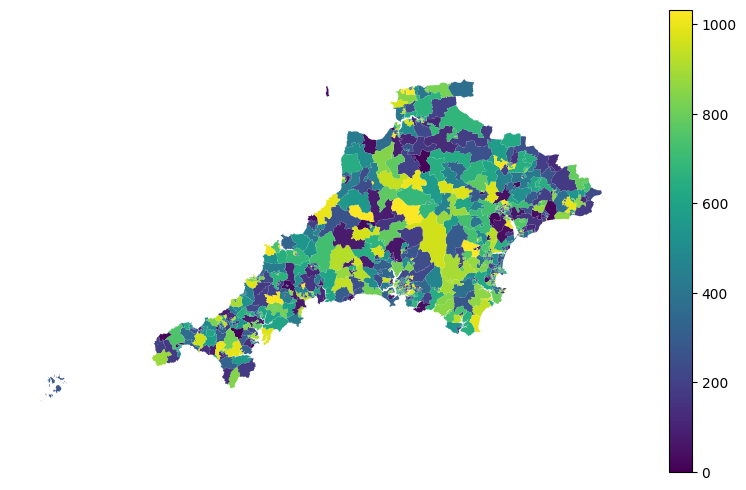

In [329]:
fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(ax=ax, column='dummy', legend=True)
ax.axis('off')
plt.show()

In [330]:
raster_sw = make_raster_from_vectors(
    gdf['geometry'],
    gdf['dummy'],
    transform_dict['height'],
    transform_dict['width'],
    transform_dict['transform']
)

Are all values integers?

In [331]:
mask = ~np.isnan(raster_sw)

(raster_sw[mask] == raster_sw[mask].astype(int)).all()

True

All values are integers so expect that the rasterisation is just assigning one LSOA to each pixel rather than doing any complicated calculation of how much area of each shape is in the pixel.

In [332]:
extent = [
    transform_dict['xmin'], #- 0.5 * transform_dict['pixel_size'],
    transform_dict['im_xmax'], # + 0.5 * transform_dict['pixel_size'],
    transform_dict['ymin'], # - 0.5 * transform_dict['pixel_size'],
    transform_dict['im_ymax'], # + 0.5 * transform_dict['pixel_size'],
]

x_mids = np.arange(extent[0] + transform_dict['pixel_size'] * 0.5, extent[1], transform_dict['pixel_size'])
y_mids = np.arange(extent[2] + transform_dict['pixel_size'] * 0.5, extent[3], transform_dict['pixel_size'])

Zoom in on Exe estuary:

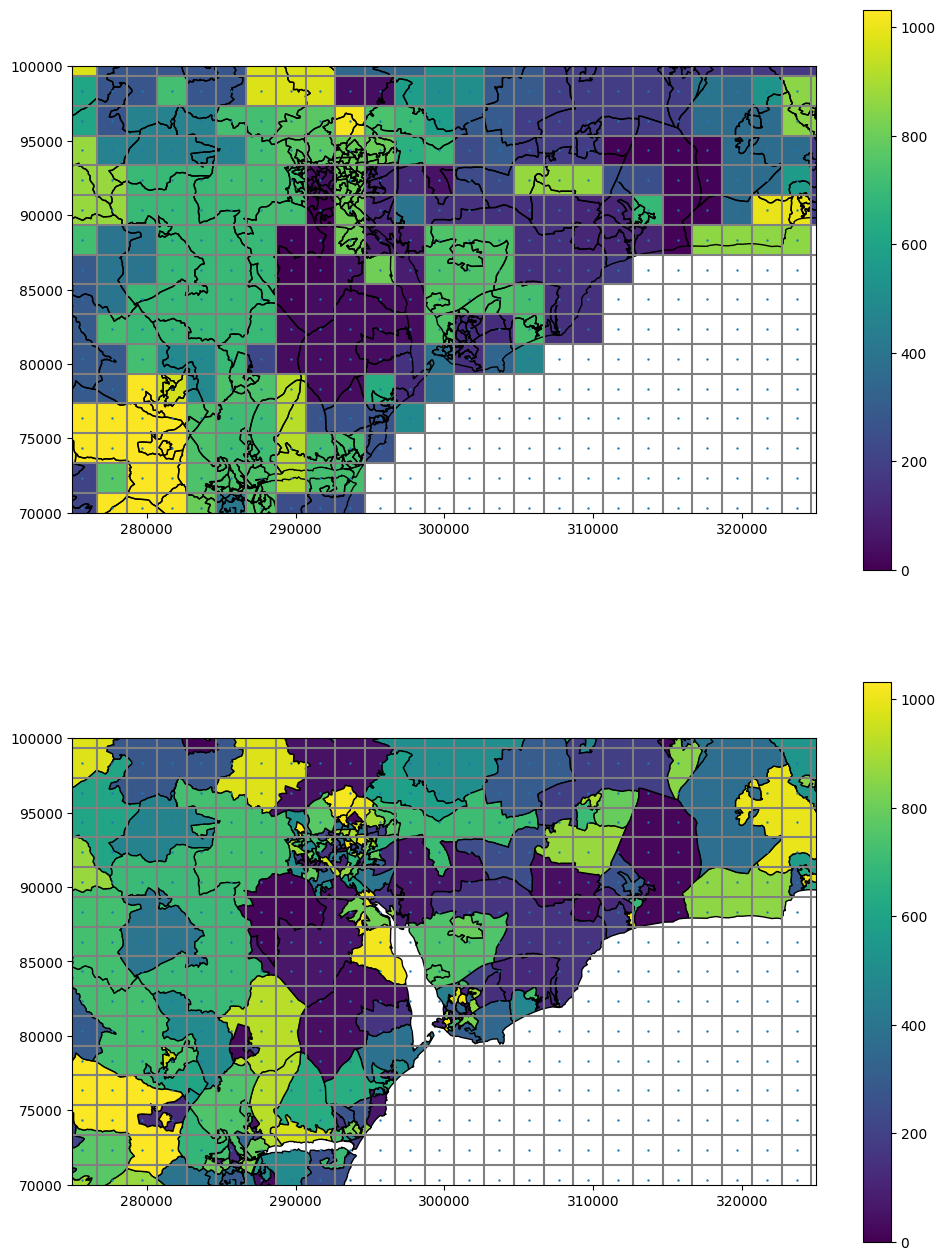

In [353]:
fig, axs = plt.subplots(2, 1, figsize=(12, 16))

# Raster:
axs[0].imshow(raster_sw, origin='lower', extent=extent)
# Geojson outline:
gdf.plot(ax=axs[0], column='dummy', legend=True, facecolor='None', edgecolor='k')

# Original data for comparison:
gdf.plot(ax=axs[1], column='dummy', legend=True, edgecolor='k')

for ax in axs:
    # Pixel borders:
    for x_mid in x_mids:
        ax.axvline(x_mid + 0.5 * transform_dict['pixel_size'], color='grey')
    for y_mid in y_mids:
        ax.axhline(y_mid + 0.5 * transform_dict['pixel_size'], color='grey')    
        
    ax.scatter(*np.meshgrid(x_mids, y_mids), s=0.5)
    
    # ax.axis('off')
    
    ax.set_xlim(275000, 325000)
    ax.set_ylim(70000, 100000)
plt.show()

## Custom value assignment

For each pixel, find which LSOA are in it and how much of the area they take up.

n.b. now fixed into British National Grid or other Cartesian systems.

In [337]:
pixel_width = transform_dict['pixel_size']
pixel_height = transform_dict['pixel_size']

extent = [
    # transform_dict['xmin'] - 0.5 * transform_dict['pixel_size'],
    # transform_dict['xmax'] + 0.5 * transform_dict['pixel_size'],
    # transform_dict['ymin'] - 0.5 * transform_dict['pixel_size'],
    # transform_dict['ymax'] + 0.5 * transform_dict['pixel_size'],
    transform_dict['xmin'], #- 0.5 * transform_dict['pixel_size'],
    transform_dict['im_xmax'], # + 0.5 * transform_dict['pixel_size'],
    transform_dict['ymin'], # - 0.5 * transform_dict['pixel_size'],
    transform_dict['im_ymax'], # + 0.5 * transform_dict['pixel_size'],
]

dict_props = {}
i = 0
for xi in range(raster_arr_maj.shape[1]):
    for yi in range(raster_arr_maj.shape[0]):
        # Pixel limits:
        pixel_limits_lrbt = [
            extent[0] + xi * pixel_width,
            extent[0] + (xi + 1) * pixel_width,
            extent[2] + yi * pixel_height,
            extent[2] + (yi + 1) * pixel_height,
        ]
        # Turn this into bounding box (xmin, ymin, xmax, ymax):
        bbox = [pixel_limits_lrbt[p] for p in [0, 2, 1, 3]]
            
        # Limit gdf to this pixel:
        gdf_here = gpd.clip(gdf, bbox).reset_index()
        # Merge multi-polygon LSOA:
        gdf_here = gdf_here.dissolve(by='FID')

        if len(gdf_here) > 0:
            # Find proportion of the constituent LSOAs by area:
            series_area_props = gdf_here.area / gdf_here.area.sum()
            # Sort LSOA IDs and proportions by decreasing proportion:
            fids = series_area_props.index.values
            props = series_area_props.values
            inds = np.argsort(props)[::-1]
    
            # Store result:
            dict_props[i] = {
                'FID': list(fids[inds]),
                'area_prop': [round(p, 3) for p in props[inds]]
            }
        # Iterate:
        i += 1

In [338]:
i

9344

In [339]:
df_props = pd.DataFrame(dict_props.values(), index=dict_props.keys())

In [340]:
df_props['FID_majority'] = [f[0] for f in df_props['FID'].tolist()]

In [341]:
df_props[200:250]

,FID,area_prop,FID_majority
3150,"[18342, 18384]","[0.968, 0.032]",18342
3151,"[18384, 18342]","[0.923, 0.077]",18384
3152,"[18384, 18342]","[0.989, 0.011]",18384
3153,[18384],[1.0],18384
3154,"[18384, 18383]","[0.998, 0.002]",18384
3155,"[18384, 18383, 18356, 18378]","[0.386, 0.259, 0.218, 0.137]",18384
3156,"[18376, 18356, 18378, 18377, 18357, 18379]","[0.536, 0.285, 0.1, 0.037, 0.032, 0.01]",18376
3157,"[18370, 18372, 18373, 18376, 18371, 18375, 183...","[0.182, 0.17, 0.16, 0.136, 0.127, 0.089, 0.069...",18370
3158,"[18370, 18372, 18354]","[0.971, 0.027, 0.002]",18370
3159,"[18287, 18354, 18370]","[0.533, 0.34, 0.127]",18287


Build a new array out of this data:

In [343]:
raster_arr_maj = np.full(raster_sw.shape, np.NaN)

for i in df_props.index:
    xi = i // raster_arr_maj.shape[0]
    yi = i % raster_arr_maj.shape[0]
    raster_arr_maj[yi, xi] = df_props.loc[i, 'FID_majority']

Convert the array to the "dummy" variable from earlier:

In [346]:
raster_arr_maj_dummy = raster_arr_maj.copy()

for i in df_props['FID_majority']:
    px = np.where(raster_arr_maj == i)
    raster_arr_maj_dummy[px] = gdf.loc[gdf.index == i, 'dummy']

View results:

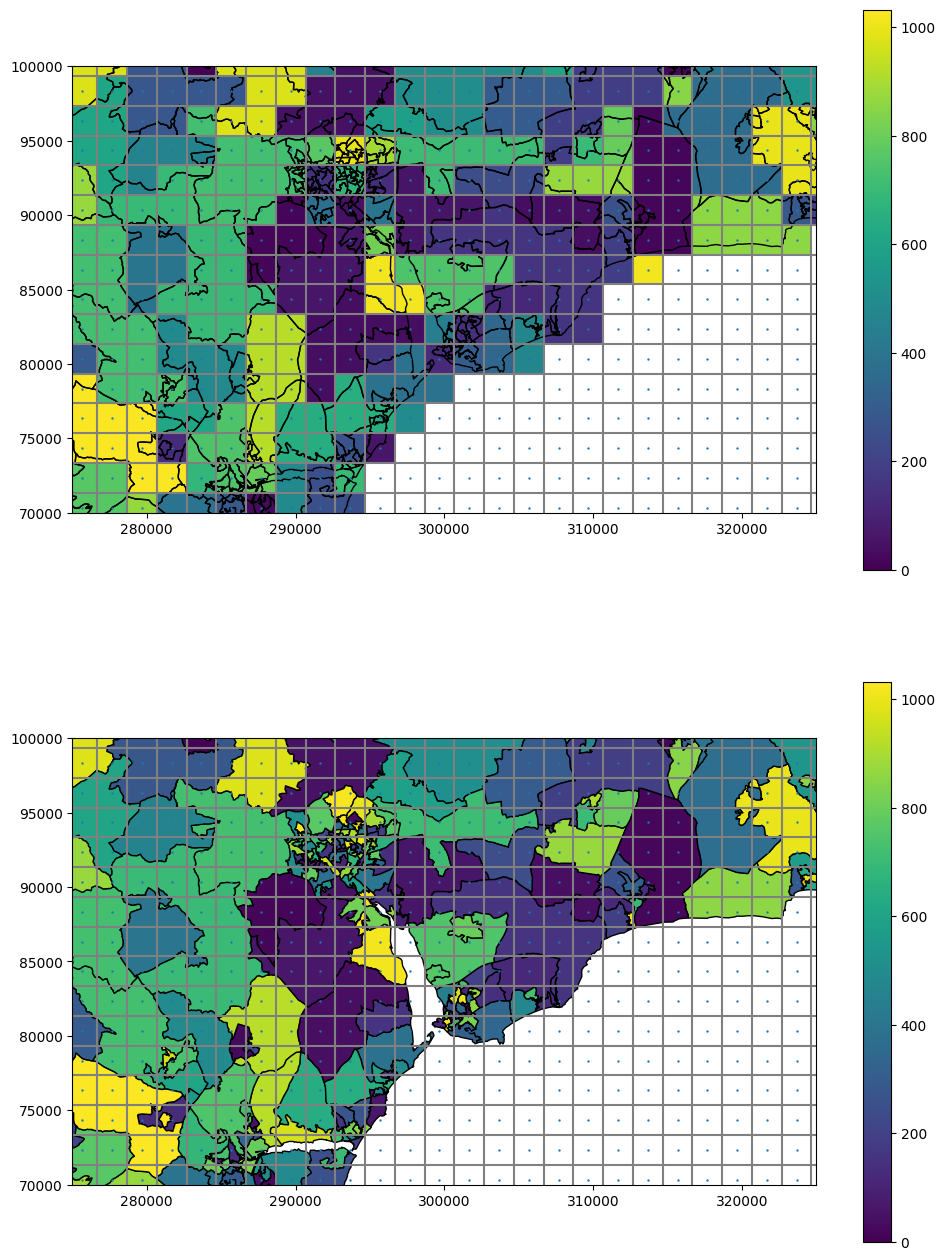

In [351]:
fig, axs = plt.subplots(2, 1, figsize=(12, 16))

# Raster:
axs[0].imshow(raster_arr_maj_dummy, origin='lower', extent=extent)
# Geojson outline:
gdf.plot(ax=axs[0], column='dummy', legend=True, facecolor='None', edgecolor='k')

# Original data for comparison:
gdf.plot(ax=axs[1], column='dummy', legend=True, edgecolor='k')


for ax in axs:
    # Pixel borders:
    for x_mid in x_mids:
        ax.axvline(x_mid + 0.5 * transform_dict['pixel_size'], color='grey')
    for y_mid in y_mids:
        ax.axhline(y_mid + 0.5 * transform_dict['pixel_size'], color='grey')
        
    ax.scatter(*np.meshgrid(x_mids, y_mids), s=0.5)
    
    # ax.axis('off')
    
    ax.set_xlim(275000, 325000)
    ax.set_ylim(70000, 100000)
plt.show()